# Multimodal XAI Framework for Real Estate Valuation
---
## Image Embedding Extraction
##

##Environment Setup

In [3]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted.")

Mounted at /content/drive
Drive mounted.


In [4]:
#Setting Paths
BASE        = '/content/drive/MyDrive/SRED_thesis'
META_DIR    = f'{BASE}/metadata'
TRAIN_IMGS  = f'{BASE}/images/train/montage_organized'
TEST_IMGS   = f'{BASE}/images/test/montage_organized'
OUTPUT_DIR  = f'{BASE}/embeddings'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verify paths exist before continuing
for path in [META_DIR, TRAIN_IMGS, TEST_IMGS]:
    exists = os.path.isdir(path)
    print(f"{'✓' if exists else '✗ MISSING'} {path}")

✓ /content/drive/MyDrive/SRED_thesis/metadata
✓ /content/drive/MyDrive/SRED_thesis/images/train/montage_organized
✓ /content/drive/MyDrive/SRED_thesis/images/test/montage_organized


##Imports and Device Check

In [ ]:
#Install & Import
import pandas as pd
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Confirming GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cpu':
    print("WARNING: No GPU detected. Embedding extraction will be slow (~2-3 hours).")
    print("Go to Runtime → Change runtime type → T4 GPU and restart.")

Device: cuda


##ResNet-50

In [ ]:
#Loading Resnet-50
import torch.nn as nn

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet.fc = nn.Identity()   # remove the 1000-class head
resnet = resnet.to(device)
resnet.eval()                # frozen — no gradient computation

total_params = sum(p.numel() for p in resnet.parameters())
print(f"ResNet-50 loaded — {total_params:,} parameters (all frozen)")
print("Output dimension: 2048")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s]


ResNet-50 loaded — 23,508,032 parameters (all frozen)
Output dimension: 2048


In [ ]:
# Image Preprocessing Pipeline

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),       # ResNet-50 expects 224×224 input
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet default channel means
        std=[0.229, 0.224, 0.225]     # ImageNet default channel stds
    )
])
print("Transform pipeline defined.")

Transform pipeline defined.


In [ ]:
# Embedding Extraction Function
# Processes images in batches for speed.
# Skips missing images and records which listing_ids failed.

def extract_embeddings(img_dir, listing_ids, batch_size=64):
    """
    For each listing_id, loads the corresponding JPEG from img_dir,
    runs it through ResNet-50, and returns a (N, 2048) embedding matrix.

    Returns:
        embeddings : np.ndarray, shape (N_found, 2048)
        valid_ids  : list of listing_ids that were successfully processed
        missing    : list of listing_ids whose image file was not found
    """
    embeddings = []
    valid_ids  = []
    missing    = []

    batch_imgs = []
    batch_ids  = []

    def run_batch(imgs, ids):
        tensor = torch.stack(imgs).to(device)
        with torch.no_grad():
            feats = resnet(tensor).cpu().numpy()
        embeddings.extend(feats)
        valid_ids.extend(ids)

    for lid in tqdm(listing_ids, desc="Extracting embeddings"):
        img_path = os.path.join(img_dir, f'{lid}.jpeg')

        if not os.path.exists(img_path):
            missing.append(lid)
            continue

        try:
            img = Image.open(img_path).convert('RGB')
            batch_imgs.append(transform(img))
            batch_ids.append(lid)
        except Exception as e:
            missing.append(lid)
            continue

        if len(batch_imgs) == batch_size:
            run_batch(batch_imgs, batch_ids)
            batch_imgs, batch_ids = [], []

    # Process remaining images in the last partial batch
    if batch_imgs:
        run_batch(batch_imgs, batch_ids)

    return np.array(embeddings), valid_ids, missing

In [ ]:
# Load metadata
train = pd.read_csv(f'{META_DIR}/train_processed.csv')
test  = pd.read_csv(f'{META_DIR}/test_processed.csv')

print(f"Train: {len(train):,} listings")
print(f"Test:  {len(test):,} listings")

Train: 9,996 listings
Test:  1,109 listings


In [ ]:
# Reload train with listing_id cast to integer, then re-run extraction

train = pd.read_csv(f'{META_DIR}/train_processed.csv')
train['listing_id'] = train['listing_id'].astype(int)

# Verify the fix
sample_ids = train['listing_id'].head(5).astype(str).tolist()
print("=== Verifying fix ===")
for sid in sample_ids:
    path = f'{TRAIN_IMGS}/{sid}.jpeg'
    found = os.path.exists(path)
    print(f"  {sid}.jpeg → exists: {found}")

=== Verifying fix ===
  4154142.jpeg → exists: True
  4447621.jpeg → exists: True
  4661232.jpeg → exists: True
  4832272.jpeg → exists: True
  4284917.jpeg → exists: True


In [ ]:
# Extract train embeddings
# This cell takes ~15-25 minutes on a T4 GPU

print("Extracting TRAIN embeddings...")
train_embs, train_valid_ids, train_missing = extract_embeddings(
    TRAIN_IMGS, train['listing_id'].tolist()
)

print(f"\nTrain results:")
print(f"  Extracted: {len(train_valid_ids):,}")
print(f"  Missing:   {len(train_missing):,}")
print(f"  Embedding shape: {train_embs.shape}")

Extracting TRAIN embeddings...


Extracting embeddings:  17%|█▋        | 1694/9996 [26:42<2:07:39,  1.08it/s]

In [ ]:
test = pd.read_csv(f'{META_DIR}/test_processed.csv')
test['listing_id'] = test['listing_id'].astype(int)

print("Extracting TEST embeddings...")
test_embs, test_valid_ids, test_missing = extract_embeddings(
    TEST_IMGS, test['listing_id'].tolist()
)

print(f"\nTest results:")
print(f"  Extracted: {len(test_valid_ids):,}")
print(f"  Missing:   {len(test_missing):,}")
print(f"  Embedding shape: {test_embs.shape}")

Extracting TEST embeddings...


Extracting embeddings: 100%|██████████| 1109/1109 [00:09<00:00, 117.14it/s]


Test results:
  Extracted: 1,109
  Missing:   0
  Embedding shape: (1109, 2048)


## PCA Dimensionality Reduction
---
The raw ResNet-50 output is a 2048-dimensional vector per image. Feeding all 2048 dimensions directly into the downstream model alongside the 5 tabular features would create a severe dimensionality imbalance and substantially increase training time.

PCA is applied to reduce the visual feature space to 128 components while retaining the majority of the variance.

The scaler and PCA object are fitted on the training set only, then applied to the test set to stay consistent with standard train/test discipline to prevent data leakage.

In [ ]:
# PCA REDUCTION
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_embs_scaled = scaler.fit_transform(train_embs)
test_embs_scaled  = scaler.transform(test_embs)

pca = PCA(n_components=128, random_state=42)
train_pca = pca.fit_transform(train_embs_scaled)
test_pca  = pca.transform(test_embs_scaled)

explained_var = pca.explained_variance_ratio_.sum() * 100
print(f"PCA: 2048d → 128d")
print(f"Variance retained: {explained_var:.1f}%")
print(f"Train PCA shape: {train_pca.shape}")
print(f"Test  PCA shape: {test_pca.shape}")

PCA: 2048d → 128d
Variance retained: 80.1%
Train PCA shape: (9996, 128)
Test  PCA shape: (1109, 128)


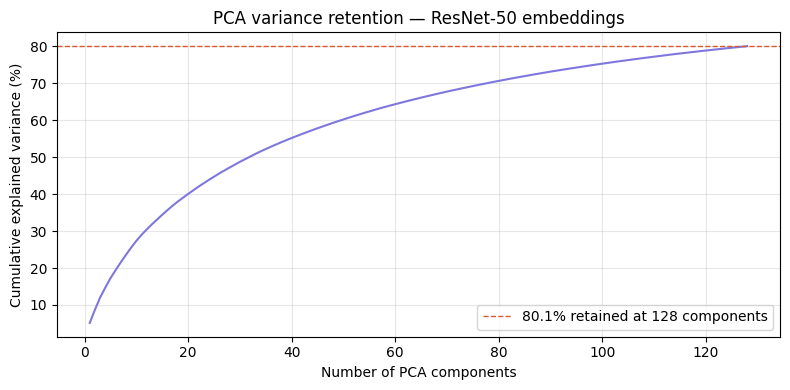

In [ ]:
# Variance explained plot
import matplotlib.pyplot as plt

cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 129), cumvar, color='#7F77DD', linewidth=1.5)
ax.axhline(y=explained_var, color='#D85A30', linestyle='--', linewidth=1,
           label=f'{explained_var:.1f}% retained at 128 components')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('PCA variance retention — ResNet-50 embeddings', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig4_pca_variance.png', bbox_inches='tight')
plt.show()

In [7]:
# Saving
import joblib

np.save(f'{OUTPUT_DIR}/train_embeddings_pca128.npy', train_pca)
np.save(f'{OUTPUT_DIR}/test_embeddings_pca128.npy',  test_pca)

pd.Series(train_valid_ids).to_csv(f'{OUTPUT_DIR}/train_valid_ids.csv', index=False)
pd.Series(test_valid_ids).to_csv(f'{OUTPUT_DIR}/test_valid_ids.csv',  index=False)

joblib.dump(scaler, f'{OUTPUT_DIR}/scaler.pkl')
joblib.dump(pca,    f'{OUTPUT_DIR}/pca128.pkl')

print("Saved successfully:")

Saved successfully:
